In [1]:
import numpy as np
import scipy


from metastable.state import FixedPointMap
from metastable.eom import EOM, Params
from metastable.manifold_inverses import calculate_manifold_inverses
from metastable.incoming_quantum_vector import extend_to_keldysh_state


fixed_point_map = FixedPointMap.load("map.npz")
epsilon_idx = -1
kappa_idx = 20
params = Params(
    epsilon=fixed_point_map.epsilon_linspace[epsilon_idx],
    kappa=fixed_point_map.kappa_linspace[kappa_idx],
    delta=fixed_point_map.delta,
    chi=fixed_point_map.chi,
)
eom = EOM(params=params)
classical_saddle_point = fixed_point_map.fixed_points[epsilon_idx, kappa_idx, 0]
classical_focus_point = fixed_point_map.fixed_points[epsilon_idx, kappa_idx, 1]
print(params)
print(classical_saddle_point, classical_focus_point)


keldysh_saddle_point = extend_to_keldysh_state(classical_saddle_point)
keldysh_focus_point = extend_to_keldysh_state(classical_focus_point)
_, saddle_point_unstable_manifold_inverse = calculate_manifold_inverses(
    keldysh_saddle_point, params
)
focus_point_stable_manifold_inverse, _ = calculate_manifold_inverses(
    keldysh_focus_point, params
)

old_vectors = np.load("bright-to-unstable.npz")

Quimb not available.
epsilon=10.0 delta=7.8 chi=-0.1 kappa=1.0
[-6.33055006  9.30242641] [-8.91507454 -9.94097263]


In [2]:
keldysh_fixed_point = keldysh_focus_point
eom = EOM(params=params)
jacobian = eom.jacobian_func(keldysh_fixed_point)
eigenvalues, eigenvectors = np.linalg.eig(jacobian)
stable_manifold_mask = eigenvalues <= 0
unstable_manifold_mask = eigenvalues > 0
stable_manifold = eigenvectors[:, stable_manifold_mask]
unstable_manifold = eigenvectors[:, unstable_manifold_mask]
inverse_eigenvectors = np.linalg.inv(eigenvectors)
inverse_unstable_manifold = inverse_eigenvectors[unstable_manifold_mask, :]
inverse_stable_manifold = inverse_eigenvectors[stable_manifold_mask, :]

In [3]:
eigenvalues

array([-1.+4.59623068j, -1.-4.59623068j,  1.+4.59623068j,  1.-4.59623068j])

In [4]:
eigenvectors[:,0]

array([ 0.74041582+0.j        , -0.59667904-0.30944876j,
        0.        +0.j        ,  0.        +0.j        ])

In [5]:
eigenvectors[:,1]

array([ 0.74041582-0.j        , -0.59667904+0.30944876j,
        0.        -0.j        ,  0.        -0.j        ])

In [6]:
np.exp(-1j*np.angle(eigenvectors[1][0]))*eigenvectors[1]

array([ 0.6721491 +9.73059351e-17j,  0.38721668-5.49406635e-01j,
       -0.59111853+3.06564977e-01j, -0.59111853+3.06564977e-01j])

In [7]:
focus_point_alt_vectors = old_vectors["vectors_orthogonal_to_stable_point_outgoing_vectors"].reshape([2, 4])

In [8]:
focus_point_alt_vectors

array([[ 0.44961254+0.j, -0.43702838+0.j,  0.32589932+0.j,
        -0.54230617+0.j],
       [-0.75816251+0.j, -0.1790094 +0.j,  0.34180082+0.j,
         0.69488549+0.j]])

In [9]:
focus_point_stable_manifold_inverse

array([[ 6.75296211e-01+1.30210604j,  0.00000000e+00+1.6157764j ,
        -3.12669726e+00+0.53335031j,  2.74262008e+00-2.07037949j],
       [ 6.75296211e-01-1.30210604j, -2.22044605e-16-1.6157764j ,
        -3.12669726e+00-0.53335031j,  2.74262008e+00+2.07037949j]])

In [10]:
np.swapaxes(old_vectors["vectors_orthogonal_to_unstable_point_incoming_vectors"], 0, 1)

array([[-7.70384188e-01,  5.56551053e-01, -2.52145687e-01,
         1.82158396e-01],
       [ 4.26512202e-17, -3.08126541e-17,  5.85602899e-01,
         8.10598078e-01]])

In [11]:
old_vectors["vectors_orthogonal_to_unstable_point_incoming_vectors"].reshape([2, 4])

array([[-7.70384188e-01,  4.26512202e-17,  5.56551053e-01,
        -3.08126541e-17],
       [-2.52145687e-01,  5.85602899e-01,  1.82158396e-01,
         8.10598078e-01]])

In [12]:
saddle_point_unstable_manifold_inverse

array([[ 1.26538463, -0.91415577,  1.86860918,  1.71406475],
       [-0.        , -0.        , -1.28104831, -1.77324138]])

In [13]:
eom = EOM(params=params)
jacobian = eom.jacobian_func(keldysh_focus_point)
eigenvalues, eigenvectors = np.linalg.eig(jacobian)

In [14]:
eigenvalues

array([-1.+4.59623068j, -1.-4.59623068j,  1.+4.59623068j,  1.-4.59623068j])

In [15]:
np.dot(old_vectors["vectors_orthogonal_to_unstable_point_incoming_vectors"].reshape([2, 4]), eigenvectors[:,0])

array([-0.57040464-1.31983671e-17j, -0.53610963-1.81214089e-01j])

In [16]:
print(np.dot(eigenvectors[:,1], old_vectors["vectors_orthogonal_to_unstable_point_incoming_vectors"]))
print(np.dot(eigenvectors[:,2], old_vectors["vectors_orthogonal_to_unstable_point_incoming_vectors"]))

[-9.02486990e-01+1.72224032e-01j  4.99649031e-17-9.53493750e-18j]
[0.81346931-0.24281264j 0.18077629+0.36666159j]


In [17]:
print(np.dot(eigenvectors[:,1], old_vectors["vectors_orthogonal_to_unstable_point_incoming_vectors"]))
print(np.dot(eigenvectors[:,2], old_vectors["vectors_orthogonal_to_unstable_point_incoming_vectors"]))

[-9.02486990e-01+1.72224032e-01j  4.99649031e-17-9.53493750e-18j]
[0.81346931-0.24281264j 0.18077629+0.36666159j]


In [18]:
eigenvalues

array([-1.+4.59623068j, -1.-4.59623068j,  1.+4.59623068j,  1.-4.59623068j])

In [19]:
np.dot(jacobian, eigenvectors[:,1]) / eigenvalues[1]

array([ 0.74041582-4.61266759e-17j, -0.59667904+3.09448757e-01j,
       -0.        -0.00000000e+00j, -0.        -0.00000000e+00j])

In [20]:
eigenvectors[:,1]

array([ 0.74041582-0.j        , -0.59667904+0.30944876j,
        0.        -0.j        ,  0.        -0.j        ])

In [21]:
np.swapaxes(old_vectors["vectors_orthogonal_to_stable_point_outgoing_vectors"], 0, 1)

array([[ 0.44961254+0.j,  0.32589932+0.j, -0.75816251+0.j,
         0.34180082+0.j],
       [-0.43702838+0.j, -0.54230617+0.j, -0.1790094 +0.j,
         0.69488549+0.j]])

In [22]:
focus_point_stable_manifold_inverse

array([[ 6.75296211e-01+1.30210604j,  0.00000000e+00+1.6157764j ,
        -3.12669726e+00+0.53335031j,  2.74262008e+00-2.07037949j],
       [ 6.75296211e-01-1.30210604j, -2.22044605e-16-1.6157764j ,
        -3.12669726e+00-0.53335031j,  2.74262008e+00+2.07037949j]])

In [23]:
test = np.vstack([focus_point_stable_manifold_inverse[0] + focus_point_stable_manifold_inverse[1], focus_point_stable_manifold_inverse[0] - focus_point_stable_manifold_inverse[1]])

[-6.33055006  9.30242641  0.          0.        ] [-8.91507454 -9.94097263  0.          0.        ]


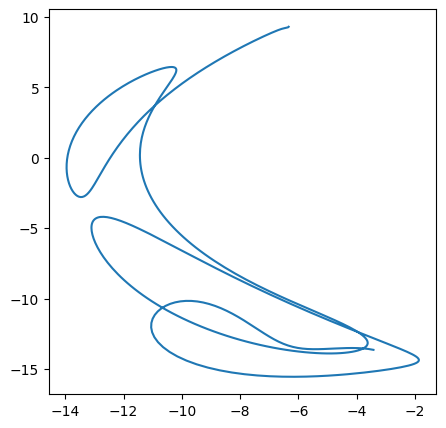

In [27]:
def bc(ya, yb):
    return np.hstack(
        [
            np.abs(np.dot(focus_point_stable_manifold_inverse, ya - keldysh_focus_point)),
            np.abs(np.dot(saddle_point_unstable_manifold_inverse, yb - keldysh_saddle_point)),
        ]
    )


print(keldysh_saddle_point, keldysh_focus_point)

t_guess = np.linspace(0.0, 8.0, 10001)
y_guess = (
    keldysh_focus_point[:, np.newaxis]
    + t_guess[np.newaxis, :]
    * (keldysh_saddle_point - keldysh_focus_point)[:, np.newaxis]
    / t_guess[-1]
)
wrapper = lambda x, y: eom.y_dot_func(y)
res = scipy.integrate.solve_bvp(
    wrapper, bc, t_guess, y_guess, tol=3e-14, max_nodes=200000
)


import matplotlib.pyplot as plt
fig, axes = plt.subplots(1,1,figsize=(5, 5))
t_plot = np.linspace(0, t_guess[-1], 1001)
y0_plot = res.sol(t_plot)[0]
y1_plot = res.sol(t_plot)[1]
axes.plot(y0_plot,y1_plot)
plt.show()


[-6.33055006  9.30242641  0.          0.        ] [-8.91507454 -9.94097263  0.          0.        ]


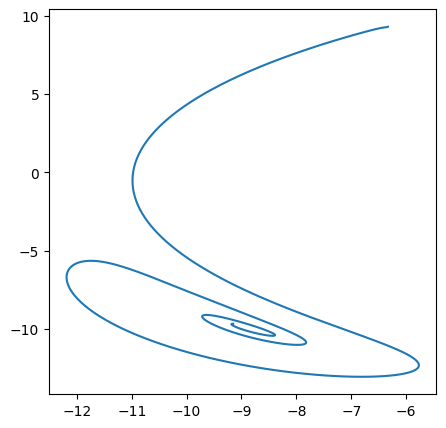

In [28]:
def bc(ya, yb):
    return np.hstack(
        [
            np.abs(np.dot(test, ya - keldysh_focus_point)),
            np.abs(np.dot(saddle_point_unstable_manifold_inverse, yb - keldysh_saddle_point)),
        ]
    )


print(keldysh_saddle_point, keldysh_focus_point)

t_guess = np.linspace(0.0, 8.0, 10001)
y_guess = (
    keldysh_focus_point[:, np.newaxis]
    + t_guess[np.newaxis, :]
    * (keldysh_saddle_point - keldysh_focus_point)[:, np.newaxis]
    / t_guess[-1]
)
wrapper = lambda x, y: eom.y_dot_func(y)
res = scipy.integrate.solve_bvp(
    wrapper, bc, t_guess, y_guess, tol=3e-14, max_nodes=200000
)


import matplotlib.pyplot as plt
fig, axes = plt.subplots(1,1,figsize=(5, 5))
t_plot = np.linspace(0, t_guess[-1], 1001)
y0_plot = res.sol(t_plot)[0]
y1_plot = res.sol(t_plot)[1]
axes.plot(y0_plot,y1_plot)
plt.show()


[-6.33055006  9.30242641  0.          0.        ] [-8.91507454 -9.94097263  0.          0.        ]


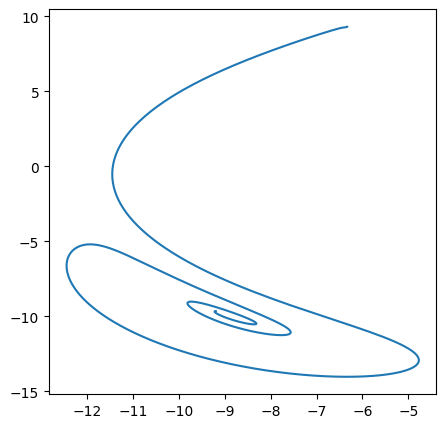

In [29]:
def bc(ya, yb):
    return np.hstack(
        [
            np.abs(np.dot(np.swapaxes(old_vectors["vectors_orthogonal_to_stable_point_outgoing_vectors"], 0, 1), ya - keldysh_focus_point)),
            np.abs(np.dot(saddle_point_unstable_manifold_inverse, yb - keldysh_saddle_point)),
        ]
    )


print(keldysh_saddle_point, keldysh_focus_point)

t_guess = np.linspace(0.0, 8.0, 10001)
y_guess = (
    keldysh_focus_point[:, np.newaxis]
    + t_guess[np.newaxis, :]
    * (keldysh_saddle_point - keldysh_focus_point)[:, np.newaxis]
    / t_guess[-1]
)
wrapper = lambda x, y: eom.y_dot_func(y)
res = scipy.integrate.solve_bvp(
    wrapper, bc, t_guess, y_guess, tol=3e-14, max_nodes=200000
)


import matplotlib.pyplot as plt
fig, axes = plt.subplots(1,1,figsize=(5, 5))
t_plot = np.linspace(0, t_guess[-1], 1001)
y0_plot = res.sol(t_plot)[0]
y1_plot = res.sol(t_plot)[1]
axes.plot(y0_plot,y1_plot)
plt.show()


[-6.33055006  9.30242641  0.          0.        ] [-8.91507454 -9.94097263  0.          0.        ]


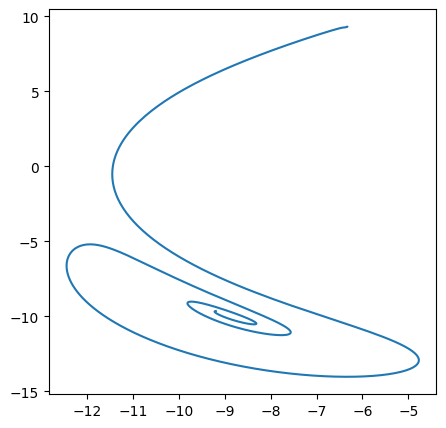

In [30]:
def bc(ya, yb):
    return np.hstack(
        [
            np.abs(np.dot(np.swapaxes(old_vectors["vectors_orthogonal_to_stable_point_outgoing_vectors"], 0, 1), ya - keldysh_focus_point)),
            np.abs(np.dot(np.swapaxes(old_vectors["vectors_orthogonal_to_unstable_point_incoming_vectors"], 0, 1), yb - keldysh_saddle_point)),
        ]
    )


print(keldysh_saddle_point, keldysh_focus_point)

t_guess = np.linspace(0.0, 8.0, 10001)
y_guess = (
    keldysh_focus_point[:, np.newaxis]
    + t_guess[np.newaxis, :]
    * (keldysh_saddle_point - keldysh_focus_point)[:, np.newaxis]
    / t_guess[-1]
)
wrapper = lambda x, y: eom.y_dot_func(y)
res = scipy.integrate.solve_bvp(
    wrapper, bc, t_guess, y_guess, tol=3e-14, max_nodes=200000
)


import matplotlib.pyplot as plt
fig, axes = plt.subplots(1,1,figsize=(5, 5))
t_plot = np.linspace(0, t_guess[-1], 1001)
y0_plot = res.sol(t_plot)[0]
y1_plot = res.sol(t_plot)[1]
axes.plot(y0_plot,y1_plot)
plt.show()


[-6.33055006  9.30242641  0.          0.        ] [-8.91507454 -9.94097263  0.          0.        ]


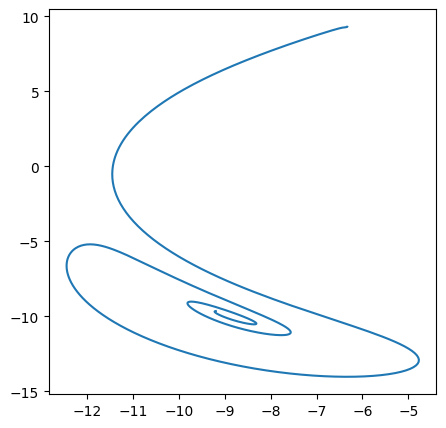

In [31]:
# def bc(ya, yb):
#     return np.hstack(
#         [
#             np.abs(np.dot(old_vectors["vectors_orthogonal_to_stable_point_outgoing_vectors"].reshape([2, 4]), ya - keldysh_focus_point)),
#             np.abs(np.dot(saddle_point_unstable_manifold_inverse, yb - keldysh_saddle_point)),
#         ]
#     )

def bc(ya, yb):
    return np.hstack(
        [
            np.abs(np.dot(np.swapaxes(old_vectors["vectors_orthogonal_to_stable_point_outgoing_vectors"], 0, 1), ya - keldysh_focus_point)),
            np.abs(np.dot(old_vectors["vectors_orthogonal_to_unstable_point_incoming_vectors"].reshape([2, 4]), yb - keldysh_saddle_point)),
        ]
    )

# def bc(ya, yb):
#     return np.hstack(
#         [
#             np.dot(focus_point_stable_manifold_inverse, ya - keldysh_focus_point),
#             np.dot(saddle_point_unstable_manifold_inverse, yb - keldysh_saddle_point),
#         ]
#     )


print(keldysh_saddle_point, keldysh_focus_point)

t_guess = np.linspace(0.0, 8.0, 10001)
y_guess = (
    keldysh_focus_point[:, np.newaxis]
    + t_guess[np.newaxis, :]
    * (keldysh_saddle_point - keldysh_focus_point)[:, np.newaxis]
    / t_guess[-1]
)
wrapper = lambda x, y: eom.y_dot_func(y)
res = scipy.integrate.solve_bvp(
    wrapper, bc, t_guess, y_guess, tol=3e-14, max_nodes=200000
)


import matplotlib.pyplot as plt
fig, axes = plt.subplots(1,1,figsize=(5, 5))
t_plot = np.linspace(0, t_guess[-1], 1001)
y0_plot = res.sol(t_plot)[0]
y1_plot = res.sol(t_plot)[1]
axes.plot(y0_plot,y1_plot)
plt.show()


[-6.33055006  9.30242641  0.          0.        ] [-8.91507454 -9.94097263  0.          0.        ]


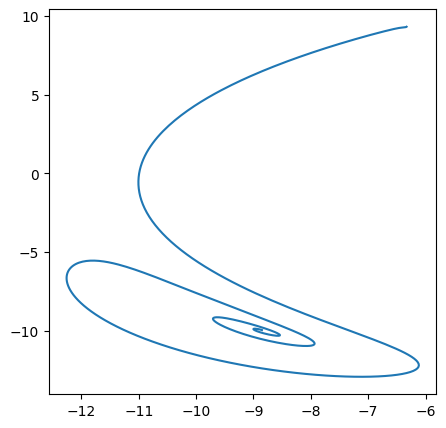

In [40]:
# def bc(ya, yb):
#     return np.hstack(
#         [
#             np.abs(np.dot(old_vectors["vectors_orthogonal_to_stable_point_outgoing_vectors"].reshape([2, 4]), ya - keldysh_focus_point)),
#             np.abs(np.dot(saddle_point_unstable_manifold_inverse, yb - keldysh_saddle_point)),
#         ]
#     )

def bc(ya, yb):
    return np.hstack(
        [
            np.abs(np.dot(old_vectors["vectors_orthogonal_to_stable_point_outgoing_vectors"].reshape([2, 4]), ya - keldysh_focus_point)),
            np.abs(np.dot(old_vectors["vectors_orthogonal_to_unstable_point_incoming_vectors"].reshape([2, 4]), yb - keldysh_saddle_point)),
        ]
    )

# def bc(ya, yb):
#     return np.hstack(
#         [
#             np.dot(focus_point_stable_manifold_inverse, ya - keldysh_focus_point),
#             np.dot(saddle_point_unstable_manifold_inverse, yb - keldysh_saddle_point),
#         ]
#     )


print(keldysh_saddle_point, keldysh_focus_point)

t_guess = np.linspace(0.0, 8.0, 10001)
y_guess = (
    keldysh_focus_point[:, np.newaxis]
    + t_guess[np.newaxis, :]
    * (keldysh_saddle_point - keldysh_focus_point)[:, np.newaxis]
    / t_guess[-1]
)
wrapper = lambda x, y: eom.y_dot_func(y)
res = scipy.integrate.solve_bvp(
    wrapper, bc, t_guess, y_guess, tol=3e-14, max_nodes=200000
)


import matplotlib.pyplot as plt
fig, axes = plt.subplots(1,1,figsize=(5, 5))
t_plot = np.linspace(0, t_guess[-1], 1001)
y0_plot = res.sol(t_plot)[0]
y1_plot = res.sol(t_plot)[1]
axes.plot(y0_plot,y1_plot)
plt.show()
